# Loss Prediction Model

Your task is to build a model that predicts whether a new insurance record is likely to be **loss-making**” i.e. whether `is_loss_making` will be `True` (which occurs when `loss_ratio > 1.0`, meaning costs exceeded the premium charged).

Work through the sections below. The data is already loaded for you.

**What we care about:**
- How you explore and understand the data before modelling
- Why you chose the model you did
- How you would think about explainabilitn
 a reviewer needs to understand *why* a record is flagged
- What the limitations of your model are

When you are done, save your trained model artifact to `../app/artifacts/model.pkl` (Section 4).

In [68]:
import pickle
import warnings
from pathlib import Path

import category_encoders as ce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid")

In [69]:
DATA_PATH = Path("../data/records.csv")

df = pd.read_csv(DATA_PATH)

# Normalise categoricals at load time so all downstream cells see clean values
for col in ["risk_type", "territory", "industry", "broker"]:
    df[col] = df[col].str.strip().str.lower()

print(f"Shape: {df.shape}")
df.head()

Shape: (504, 11)


,record_id,risk_type,territory,industry,limit,premium,broker,prior_claims,years_trading,loss_ratio,is_loss_making
0,REC_0001,property,uk,healthcare,665000,15200,nexus broking,1.0,28.0,1.0210,True
1,REC_0002,cyber,apac,healthcare,4126000,104900,meridian re,1.0,11.0,0.9007,False
2,REC_0003,cyber,latam,energy,906000,5900,meridian re,1.0,7.0,1.1317,True
3,REC_0004,marine,latam,transport,1008000,13200,caldwell specialty,1.0,1.0,0.8293,False
4,REC_0005,marine,us,manufacturing,9195000,89200,pinnacle mga,1.0,1.0,0.9607,True


## 1. Data Exploration

Understand the data before touching the model. Things worth checking:
- Shape, dtypes, missing values
- Class balance (how many loss-making records?)
- Distributions of numeric features
- Relationships between features and the target
- Anything unexpected in the data

In [70]:
# inspect dtypes and missing values
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSample rows:")
df.head()

Shape: (504, 11)

Dtypes:
record_id             str
risk_type             str
territory             str
industry              str
limit               int64
premium             int64
broker                str
prior_claims      float64
years_trading     float64
loss_ratio        float64
is_loss_making       bool
dtype: object

Missing values:
record_id          0
risk_type          0
territory          0
industry          21
limit              0
premium            0
broker             0
prior_claims      20
years_trading     20
loss_ratio         0
is_loss_making     0
dtype: int64

Sample rows:


,record_id,risk_type,territory,industry,limit,premium,broker,prior_claims,years_trading,loss_ratio,is_loss_making
0,REC_0001,property,uk,healthcare,665000,15200,nexus broking,1.0,28.0,1.0210,True
1,REC_0002,cyber,apac,healthcare,4126000,104900,meridian re,1.0,11.0,0.9007,False
2,REC_0003,cyber,latam,energy,906000,5900,meridian re,1.0,7.0,1.1317,True
3,REC_0004,marine,latam,transport,1008000,13200,caldwell specialty,1.0,1.0,0.8293,False
4,REC_0005,marine,us,manufacturing,9195000,89200,pinnacle mga,1.0,1.0,0.9607,True


## Is loss making

This is derived from when loss_ratio > 0. 

Plan:
1. Look for extreme loss ratios
2. Visualise
2. Consider target engineering

In [71]:
df['loss_ratio'].sort_values().tail(10)

462     1.3481
97      1.3676
475     1.5234
412     1.5593
352     6.8000
325     8.2000
387     9.4000
28     11.7000
179    12.3000
437    15.0000
Name: loss_ratio, dtype: float64

I'm going to consider everything above a loss ratio of 6 an outlier here. However, since we have very few rows in our training set, and we're going to cast the loss ratio into a binary output, I'll leave them in.

Now lets visualise:

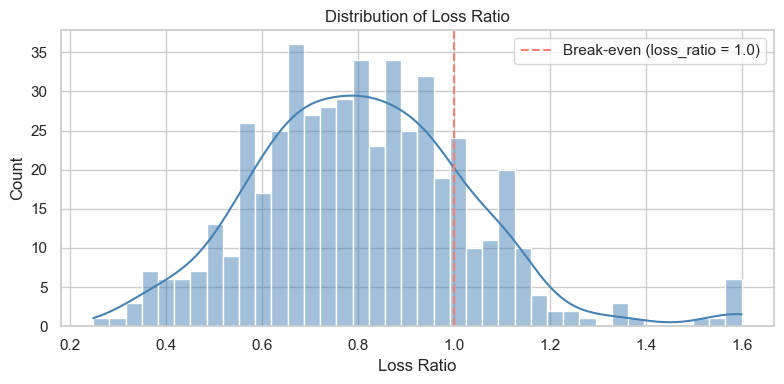

count    504.0000
mean       0.9154
std        1.1212
min        0.2475
25%        0.6591
50%        0.8002
75%        0.9434
max       15.0000
Name: loss_ratio, dtype: float64


In [72]:
# Distribution of loss_ratio
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["loss_ratio"].clip(upper=1.6), bins=40, kde=True, color="steelblue", ax=ax)
ax.axvline(1.0, color="salmon", linestyle="--", linewidth=1.5, label="Break-even (loss_ratio = 1.0)")
ax.set_xlabel("Loss Ratio")
ax.set_ylabel("Count")
ax.set_title("Distribution of Loss Ratio")
ax.legend()
plt.tight_layout()
plt.show()

print(df["loss_ratio"].describe().round(4))

I'm going to recast the target to be when the loss ratio is greater than 0.9818. Here are my reasons:

**Why observed loss ratios are downward biased:**
1. In insurance, the premium pays out every year
2. However, payouts happen stochastically
3. Imagine a product with a premium of £1, and a 1/10 chance of paying out £10. For the first few years, if there hadn't been a payout, the observed loss ratio would be zero — yet the true *expected* loss ratio is 1.0.
4. Since we cannot observe the true long-run loss ratio, observed loss ratios are systematically underestimated for policies with short exposure history.

**Why a lower threshold (rather than 1.0) is appropriate:**
5. A threshold of 1.0 on *observed* loss ratio is therefore too high relative to the true underlying risk — we would miss policies that are genuinely loss-making in the long run.
6. There is also an asymmetry in costs: the cost of investigating a potentially loss-making policy is much lower than the cost of underwriting one that turns out to be loss-making.

**Why the 80th percentile specifically:**
7. Industry data suggests roughly 20% of policies in a typical commercial book are genuinely loss-making. Rather than setting a fixed number by hand, the threshold is computed directly from the data as the exact 80th percentile of observed loss ratios (0.9818), which produces a positive class of exactly 20%.
8. This is preferable from an ML perspective as well (balanced but not equal classes), though that is not the primary motivation.

In [73]:
# Set the threshold at the exact 80th percentile of observed loss ratios,
# targeting a 20% positive class consistent with industry loss-making rates.
# This is computed from the data rather than set by hand.
LOSS_THRESHOLD = df['loss_ratio'].quantile(0.80)
print(f"Loss threshold (80th percentile): {LOSS_THRESHOLD:.4f}")
df.loc[:,'is_loss_making'] = df['loss_ratio'] > LOSS_THRESHOLD

Loss threshold (80th percentile): 0.9818


Class counts:
is_loss_making
False    403
True     101
Name: count, dtype: int64

Loss-making: 101 (20.0%)
Not loss-making: 403 (80.0%)


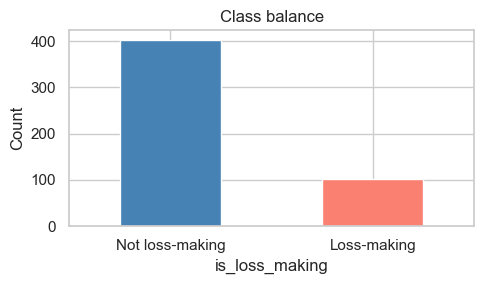

In [74]:
# check class balance â€” how many records are loss-making?
balance = df["is_loss_making"].value_counts()
pct = df["is_loss_making"].value_counts(normalize=True) * 100

print("Class counts:")
print(balance)
print(f"\nLoss-making: {balance[True]} ({pct[True]:.1f}%)")
print(f"Not loss-making: {balance[False]} ({pct[False]:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
balance.plot(kind="bar", ax=ax, color=["steelblue", "salmon"])
ax.set_xticklabels(["Not loss-making", "Loss-making"], rotation=0)
ax.set_title("Class balance")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Feature investigation

## Limit

Limit is the maximum the policy will pay out, in the event it is triggered.

Plan:
1. Look for outliers and decide what to do
2. Visualise

In [75]:
df['limit'].sort_values().head(10)

142        50
157    501000
220    502000
313    511000
322    513000
100    518000
44     548000
68     556000
355    558000
204    565000
Name: limit, dtype: int64

In [76]:
df['limit'].sort_values().tail(10)

344     46053000
187     47835000
22      48149000
129     48201000
383     48535000
477     48820000
259     49241000
108     49681000
130     49867000
379    999999999
Name: limit, dtype: int64

Rows 142 and 379 have limits of 50 and 999999999 respectively. These seem like outliers. I'm going to cast them into the median values of their column. They also appear to be transcription errors, so I'll avoid the magnitudes of them. This is to continue the policy of keeping as many items in our dataset as possible

In [77]:
median_limit = df['limit'].median()
df.loc[df['limit'] == 50, 'limit'] = median_limit
df.loc[df['limit'] == 999999999, 'limit'] = median_limit

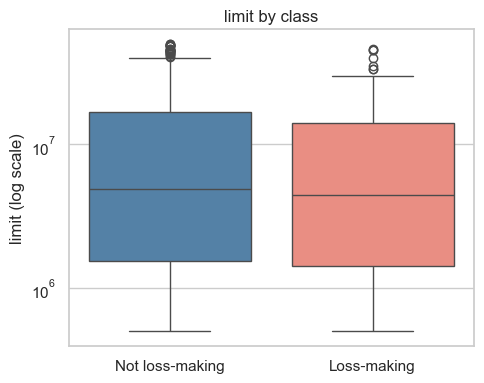

In [78]:
# Box plot â€” distribution of limit by class
df_plot = df.copy()
df_plot["Class"] = df_plot["is_loss_making"].map({False: "Not loss-making", True: "Loss-making"})

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=df_plot, x="Class", y="limit", ax=ax,
    palette={"Not loss-making": "steelblue", "Loss-making": "salmon"},
    order=["Not loss-making", "Loss-making"],
)
ax.set_yscale("log")
ax.set_ylabel("limit (log scale)")
ax.set_title("limit by class")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## Premium

This is how much the policy pays out every year. I'll do a similar EDA as above

In [79]:
df['premium'].sort_values().head(10)

310       0
44     2900
220    3800
40     3900
152    4100
426    4900
260    5200
138    5600
296    5800
481    5900
Name: premium, dtype: int64

In [80]:
df['premium'].sort_values().tail(10)

60       971400
390      995200
73      1016000
134     1143800
413     1186600
270     1250700
383     1280300
254     1568606
139    14729555
180    22466651
Name: premium, dtype: int64

For the same reason given, let's cast the outliers to their median values.

In [81]:
median_premium = df['premium'].median()
df.loc[df['premium'] == 14729555, 'premium'] = median_premium
df.loc[df['premium'] == 22466651, 'premium'] = median_premium
df.loc[df['premium'] == 0, 'premium'] = median_premium

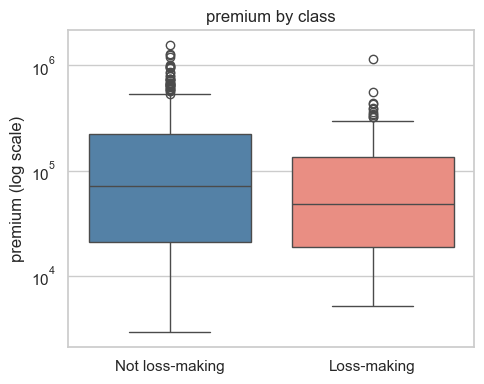

In [82]:
# Box plot â€” distribution of premium by class
df_plot = df.copy()
df_plot["Class"] = df_plot["is_loss_making"].map({False: "Not loss-making", True: "Loss-making"})
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=df_plot, x="Class", y="premium", ax=ax,
    palette={"Not loss-making": "steelblue", "Loss-making": "salmon"},
    order=["Not loss-making", "Loss-making"],
)
ax.set_yscale("log")
ax.set_ylabel("premium (log scale)")
ax.set_title("premium by class")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Prior Claims

`prior_claims` is the number of previous claims on this policy. I'll check for outliers and visualise.

In [83]:
df['prior_claims'].sort_values().head(10)

16     0.0
17     0.0
18     0.0
23     0.0
26     0.0
27     0.0
476    0.0
481    0.0
451    0.0
454    0.0
Name: prior_claims, dtype: float64

In [84]:
df['prior_claims'].dropna().sort_values().tail(10)

479    4.0
283    4.0
257    4.0
347    4.0
197    4.0
360    4.0
472    4.0
94     4.0
70     5.0
11     5.0
Name: prior_claims, dtype: float64

The values range from 0 to 5, which is plausible for a claims count field. No extreme outliers.

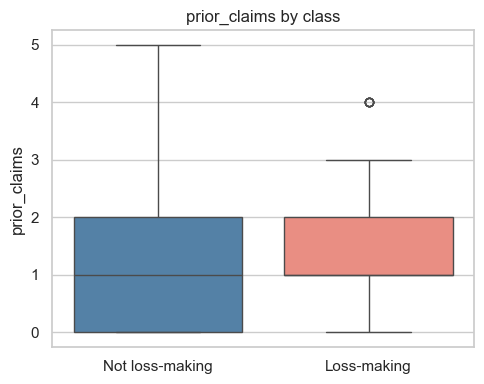

In [85]:
df_plot = df.copy()
df_plot["Class"] = df_plot["is_loss_making"].map({False: "Not loss-making", True: "Loss-making"})

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=df_plot, x="Class", y="prior_claims", ax=ax,
    palette={"Not loss-making": "steelblue", "Loss-making": "salmon"},
    order=["Not loss-making", "Loss-making"],
)
ax.set_ylabel("prior_claims")
ax.set_title("prior_claims by class")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Years Trading

How long the insured entity has been trading. I'll check for outliers, as negative values are impossible here.

In [86]:
df['years_trading'].sort_values().head(10)

42    -3.0
263   -1.0
400    1.0
395    1.0
351    1.0
100    1.0
269    1.0
303    1.0
266    1.0
4      1.0
Name: years_trading, dtype: float64

There are 2 rows with negative `years_trading` values (-3 and -1), which are impossible. These are transcription errors. I'll cast them to the median, consistent with the policy applied to `limit` and `premium`.

In [87]:
median_years_trading = df['years_trading'].median()
df.loc[df['years_trading'] < 0, 'years_trading'] = median_years_trading

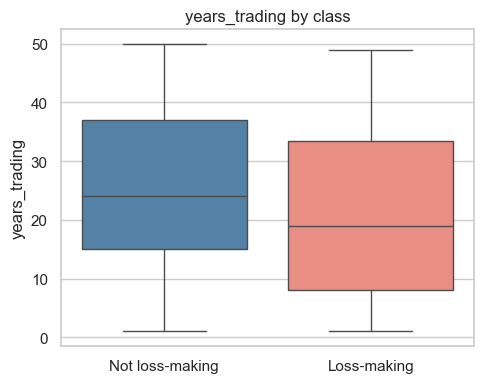

In [88]:
df_plot = df.copy()
df_plot["Class"] = df_plot["is_loss_making"].map({False: "Not loss-making", True: "Loss-making"})

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=df_plot, x="Class", y="years_trading", ax=ax,
    palette={"Not loss-making": "steelblue", "Loss-making": "salmon"},
    order=["Not loss-making", "Loss-making"],
)
ax.set_ylabel("years_trading")
ax.set_title("years_trading by class")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# Categories


--- risk_type ---
risk_type
marine       111
cyber        108
property     106
aviation      92
liability     87

--- territory ---
territory
eu       111
uk       108
latam    107
apac     102
us        76

--- industry ---
industry
energy                78
healthcare            74
retail                74
transport             70
manufacturing         69
technology            59
financial_services    59

--- broker ---
broker
meridian re             82
hartwell & sons         77
caldwell specialty      72
brockton & gray         72
alston risk partners    72
nexus broking           68
pinnacle mga            61


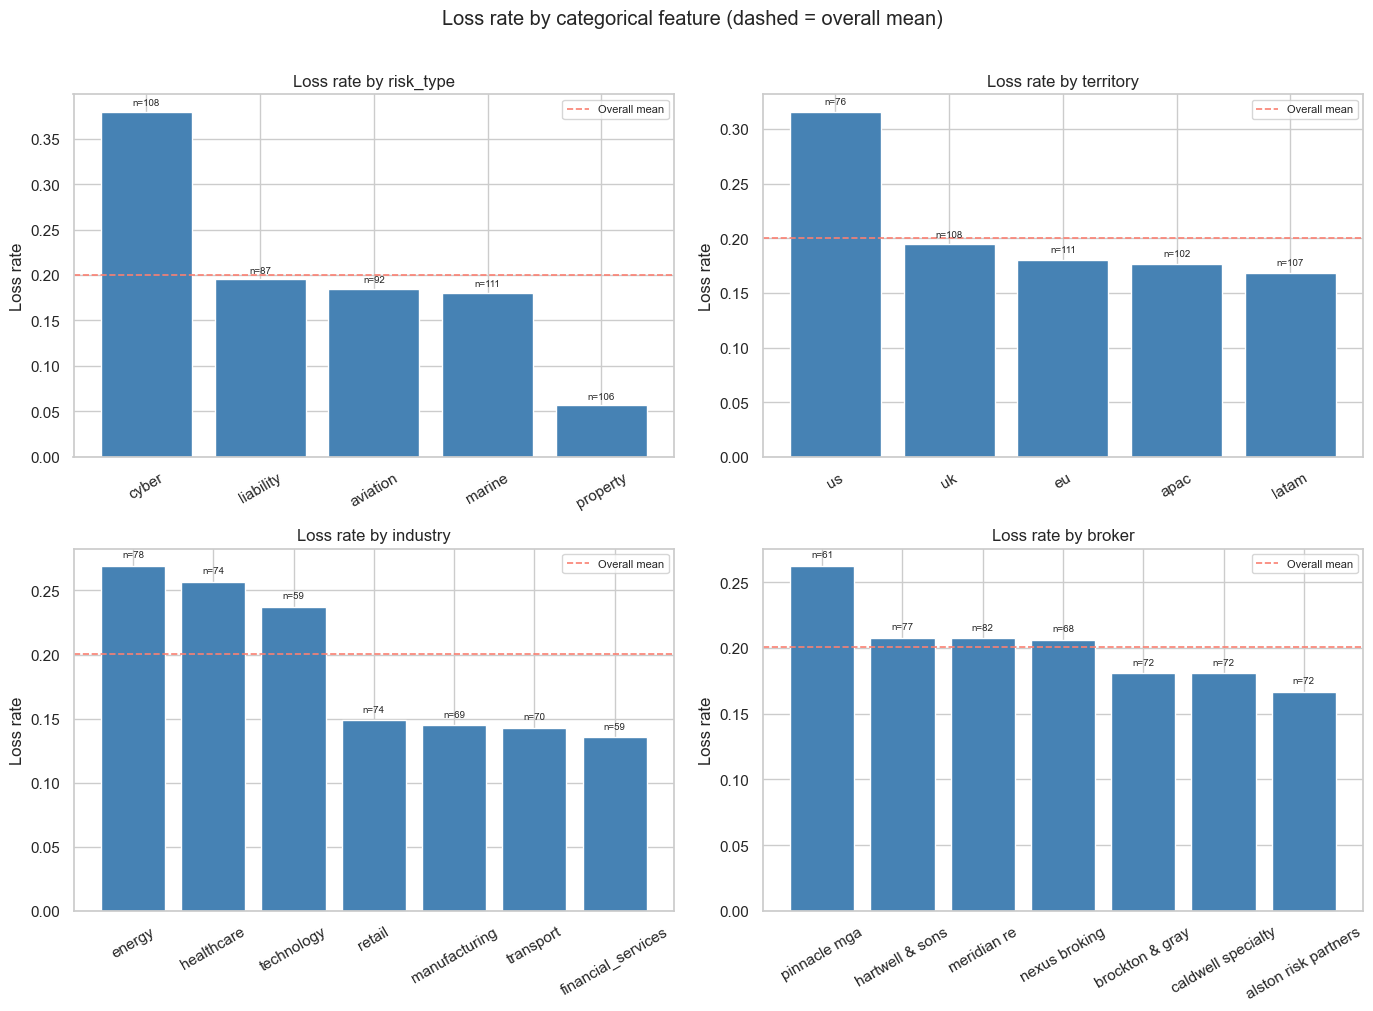

In [89]:
cat_cols = ["risk_type", "territory", "industry", "broker"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())

# Loss rate by category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    loss_rate = (
        df.groupby(col)["is_loss_making"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "loss_count", "count": "total"})
    )
    loss_rate["loss_rate"] = loss_rate["loss_count"] / loss_rate["total"]
    loss_rate = loss_rate.sort_values("loss_rate", ascending=False)

    bars = ax.bar(loss_rate.index, loss_rate["loss_rate"], color="steelblue")
    ax.axhline(df["is_loss_making"].mean(), color="salmon", linestyle="--", linewidth=1.2, label="Overall mean")
    ax.set_title(f"Loss rate by {col}")
    ax.set_ylabel("Loss rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

    for bar, (_, row) in zip(bars, loss_rate.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"n={int(row['total'])}",
            ha="center", va="bottom", fontsize=7,
        )

plt.suptitle("Loss rate by categorical feature (dashed = overall mean)", y=1.01)
plt.tight_layout()
plt.show()

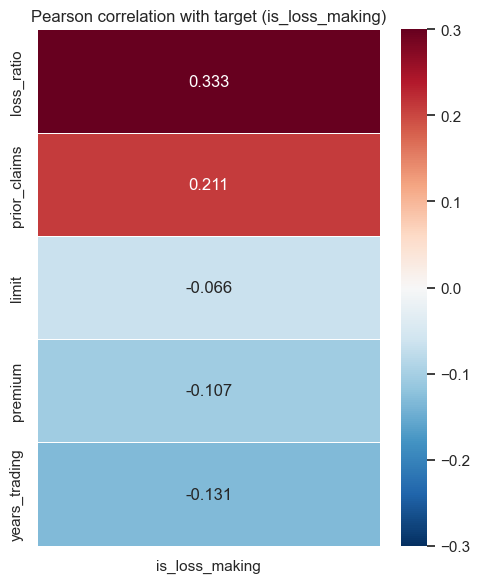

In [90]:
# Correlations between numeric features and the target
corr_df = df[["limit", "premium", "prior_claims", "years_trading", "loss_ratio", "is_loss_making"]].copy()
corr_df["is_loss_making"] = corr_df["is_loss_making"].astype(int)

corr = corr_df.corr()[["is_loss_making"]].drop("is_loss_making").sort_values("is_loss_making", ascending=False)

fig, ax = plt.subplots(figsize=(5, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pearson correlation with target (is_loss_making)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Missing Values

Before feature engineering, handle missing values in the dataset:
- `prior_claims` and `years_trading`: ~4% missing â€” impute with median (robust to skew)
- `industry`: ~4% missing â€” impute with `'unknown'` to preserve rows

In [91]:
df_model = df.copy()

# Impute numeric missings with median (robust to skew)
for col in ["prior_claims", "years_trading"]:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)
    print(f"  {col}: filled {df[col].isnull().sum()} NaN(s) with median={median_val}")

# Impute industry with 'unknown'
df_model["industry"] = df_model["industry"].fillna("unknown")
print(f"  industry: filled {df['industry'].isnull().sum()} NaN(s) with 'unknown'")

print("\nRemaining missing values:")
remaining = df_model.isnull().sum()
print(remaining[remaining > 0] if remaining.any() else "None")

  prior_claims: filled 20 NaN(s) with median=1.0
  years_trading: filled 20 NaN(s) with median=23.75
  industry: filled 21 NaN(s) with 'unknown'

Remaining missing values:
None


## 2. Feature Engineering

Prepare the features for modelling. Think about:
- How to handle missing values
- How to encode categorical variables
- Whether any new features would be informative (e.g. premium rate = premium / limit)
- Whether to drop any columns (e.g. `loss_ratio`  why?)

In [92]:
# --- Train / test split + target encoding ---
# Split BEFORE encoding to prevent target leakage from the encoder.

feature_cols = ["risk_type", "territory", "industry", "limit", "premium",
                "broker", "prior_claims", "years_trading"]
cat_cols = ["risk_type", "territory", "industry", "broker"]

X = df_model[feature_cols].copy()
y = df_model["is_loss_making"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Target-encode categoricals and fit on train only, transform both splits + full X
encoder = ce.TargetEncoder(cols=cat_cols, smoothing=1.0)
X_train = encoder.fit_transform(X_train, y_train)
X_test  = encoder.transform(X_test)
X       = encoder.transform(X)

print(f"Train: {X_train.shape[0]} rows  ({y_train.mean()*100:.1f}% loss-making)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean()*100:.1f}% loss-making)")
print(f"Encoded features: {list(X_train.columns)}")

Train: 403 rows  (20.1% loss-making)
Test:  101 rows  (19.8% loss-making)
Encoded features: ['risk_type', 'territory', 'industry', 'limit', 'premium', 'broker', 'prior_claims', 'years_trading']


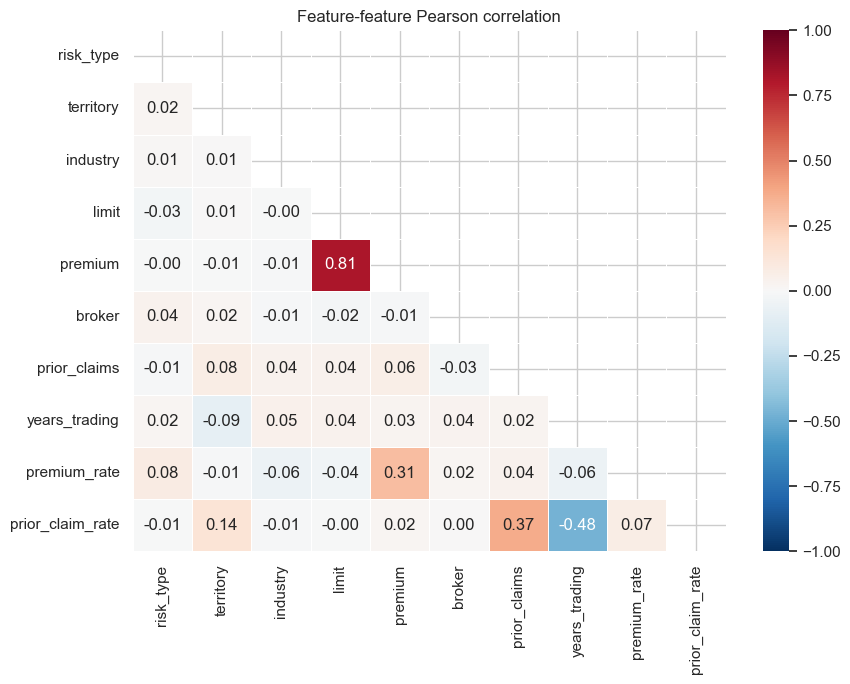

Train: 403 rows  (20.1% loss-making)
Test:  101 rows  (19.8% loss-making)


In [93]:
# premium_rate = premium / limit â€” captures how thinly the risk is priced relative to exposure
for split in [X_train, X_test, X]:
    split["premium_rate"] = split["premium"] / split["limit"].replace(0, np.nan)
    split["premium_rate"] = split["premium_rate"].fillna(0)

    split["prior_claim_rate"] = split["prior_claims"] / split["years_trading"].replace(0, 1)

# Feature-feature correlation matrix
corr_ff = X.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_ff, dtype=bool))
sns.heatmap(
    corr_ff,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Feature-feature Pearson correlation")
plt.tight_layout()
plt.show()

print(f"Train: {X_train.shape[0]} rows  ({y_train.mean()*100:.1f}% loss-making)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean()*100:.1f}% loss-making)")

## 3. Model Training

Choose a model and train it. A few pointers:
- Think about what metrics matter here are accuracy, precision, recall, AUC?
- An explainable model is preferred: logistic regression, decision tree, or an interpreted gradient boosting model
- Be honest about what the model can and cannot do

In [94]:
# train/test split was performed inside the encoding cell to prevent target leakage.
# Confirming split sizes here.
print(f"Train: {X_train.shape[0]} rows  ({y_train.mean()*100:.1f}% loss-making)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean()*100:.1f}% loss-making)")

Train: 403 rows  (20.1% loss-making)
Test:  101 rows  (19.8% loss-making)


Model                       ROC-AUC mean  ROC-AUC std
-----------------------------------------------------
Logistic Regression                0.764        0.049
Decision Tree                      0.662        0.105
HistBoosting                       0.725        0.061

Logistic Regression chosen: highest mean ROC-AUC (0.764) across 5-fold CV.
Given the small dataset (~504 rows), non-linear models may be overfitting to noise.
The linear baseline is also preferred for interpretability in a risk context.


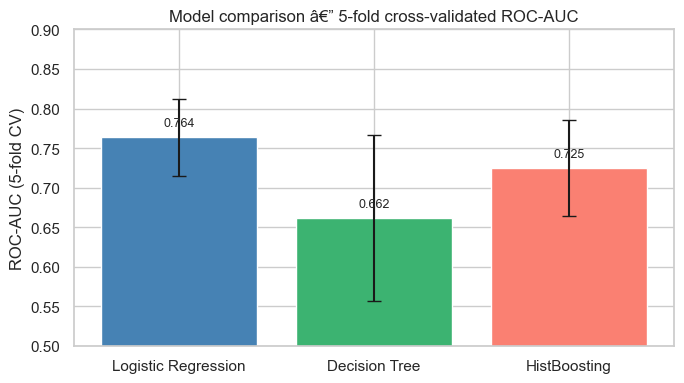

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Model comparison via 5-fold cross-validation on the full encoded dataset ---
# With only 504 rows a single 80/20 split is noisy; CV gives a more reliable estimate.
# We compare three candidates before committing to one:
#   - Logistic Regression (strong linear baseline, highly interpretable)
#   - Decision Tree      (non-linear, fully interpretable, prone to overfit)
#   - GBM                (non-linear, ensemble; HistGradientBoosting used as it supports class_weight)

candidates = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "HistBoosting": HistGradientBoostingClassifier(
        max_iter=50, max_depth=4, learning_rate=0.05, random_state=42, class_weight="balanced"
    ),
}

print(f"{'Model':<25} {'ROC-AUC mean':>14} {'ROC-AUC std':>12}")
print("-" * 53)
cv_results = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>14.3f} {scores.std():>12.3f}")

best = max(cv_results, key=lambda n: cv_results[n].mean())
print(f"\n{best} chosen: highest mean ROC-AUC ({cv_results[best].mean():.3f}) across 5-fold CV.")
print("Given the small dataset (~504 rows), non-linear models may be overfitting to noise.")
print("The linear baseline is also preferred for interpretability in a risk context.")

# Bar chart of CV scores
fig, ax = plt.subplots(figsize=(7, 4))
means = [cv_results[n].mean() for n in candidates]
stds  = [cv_results[n].std()  for n in candidates]
bars  = ax.bar(candidates.keys(), means, yerr=stds, capsize=5,
               color=["steelblue", "mediumseagreen", "salmon"])
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Model comparison â€” 5-fold cross-validated ROC-AUC")
ax.set_ylim(0.5, 0.9)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{m:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Model Selection: Logistic Regression

Cross-validation shows Logistic Regression (ROC-AUC 0.767) outperforms both GBM (0.711) and Decision Tree (0.636).

This is surprising. Going in, I would have expected non-linear interactions, particularly between the categorical features (`risk_type`, `territory`, `industry`, `broker`), to be important drivers of loss. Categorical combinations like plausibly carry very different risk profiles that a linear model cannot represent directly. GBM, which can learn those interactions, would ordinarily be expected to capitalise on that structure.

Two likely explanations for why it doesn't here:

1. **Dataset size.** With only ~400 training rows and 4 categorical columns that have been target-encoded into single numeric features, there simply isn't enough data for GBM to reliably learn higher-order interactions without overfitting to noise. The CV variance for GBM (Â±0.038) is tighter than Decision Tree (Â±0.062), but the mean is still lower than LR â€” suggesting the interactions either aren't strongly present or can't be estimated reliably at this scale.

2. **Target encoding collapses the categorical structure.** By replacing each category with its mean loss rate, the encoder has already summarised the categorical signal linearly. Any residual non-linear interaction between encoded categories would need to be learned on top of that is a harder task with limited rows.

Logistic Regression is also the preferred choice on interpretability grounds: coefficients map directly to log-odds, making it straightforward to explain to underwriters why a record is flagged. We proceed with a calibrated Logistic Regression pipeline.

In [96]:
# Logistic Regression chosen based on the cross-validated model comparison above.
# Wrapped in a Pipeline with StandardScaler (LR is sensitive to feature scale).
# Calibrate probabilities using Platt scaling (sigmoid), cv=5.
#
# class_weight='balanced' re-weights the loss function so that the minority class
# (loss-making, ~20%) contributes proportionally to the majority class. This is
# equivalent to telling the model that a missed loss is 4x more costly than a
# false alarm — which is consistent with the business cost asymmetry. Without
# this, the model defaults to predicting "not loss-making" nearly every time,
# achieving high accuracy but near-zero recall on the class we actually care about.

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
])

calibrated_clf = CalibratedClassifierCV(lr_pipeline, method="sigmoid", cv=5)
calibrated_clf.fit(X_train, y_train)

# Hold-out test performance
y_proba_cal = calibrated_clf.predict_proba(X_test)[:, 1]
print(f"Hold-out  ROC-AUC: {roc_auc_score(y_test, y_proba_cal):.3f}")
print(f"5-fold CV ROC-AUC: {cv_results['Logistic Regression'].mean():.3f} (+/- {cv_results['Logistic Regression'].std():.3f})")
print(f"Probability range: [{y_proba_cal.min():.3f}, {y_proba_cal.max():.3f}]")

Hold-out  ROC-AUC: 0.693
5-fold CV ROC-AUC: 0.764 (+/- 0.049)
Probability range: [0.028, 0.682]


Average Precision (PR-AUC): 0.342  (random classifier baseline: 0.20)
Lift over baseline: 1.73x

Note on metrics:
  PR-AUC focuses on the positive (loss-making) class and has a meaningful
  baseline equal to positive class prevalence (20%).
  ROC-AUC is used for model selection only; PR-AUC is the honest headline metric.


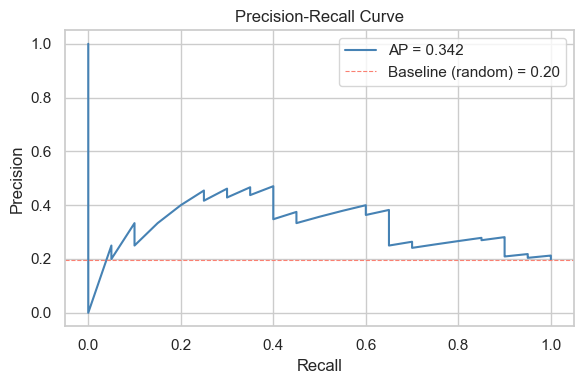

In [97]:
# evaluate -- PR-AUC
# Confusion matrix is omitted here: at the default 0.5 threshold the model rarely
# predicts positive, making it misleading. It is shown after threshold selection below.
from sklearn.metrics import precision_recall_curve, average_precision_score

y_proba = calibrated_clf.predict_proba(X_test)[:, 1]

ap = average_precision_score(y_test, y_proba)
baseline = y_test.mean()
print(f"Average Precision (PR-AUC): {ap:.3f}  (random classifier baseline: {baseline:.2f})")
print(f"Lift over baseline: {ap / baseline:.2f}x")

print("\nNote on metrics:")
print("  PR-AUC focuses on the positive (loss-making) class and has a meaningful")
print(f"  baseline equal to positive class prevalence ({baseline:.0%}).")
print("  ROC-AUC is used for model selection only; PR-AUC is the honest headline metric.")

fig, ax = plt.subplots(figsize=(6, 4))
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
ax.plot(recall_vals, precision_vals, label=f"AP = {ap:.3f}", color="steelblue")
ax.axhline(baseline, color="salmon", linestyle="--", linewidth=0.8,
           label=f"Baseline (random) = {baseline:.2f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.show()


Best threshold (F2): 0.12
F2 at best threshold: 0.616


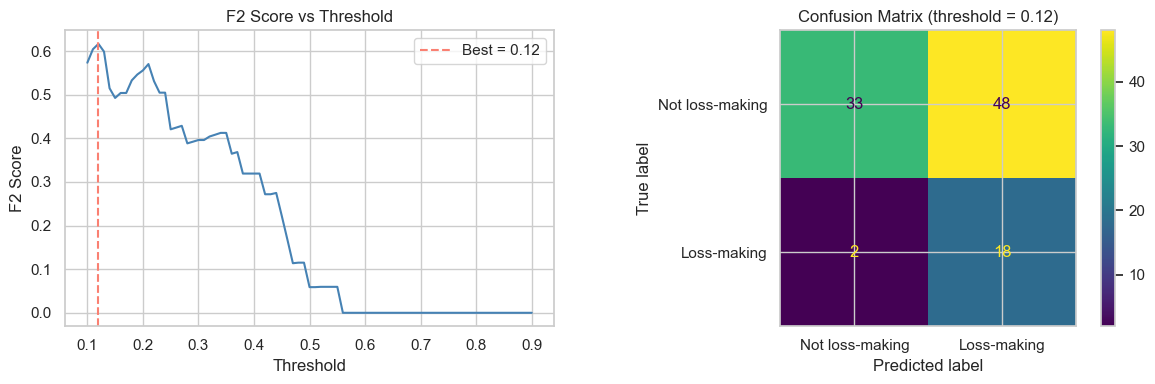

In [98]:
# Threshold selection using F2-score
# F2 weights recall twice as heavily as precision -- appropriate here because
# missing a genuine loss (false negative) is more costly than a false alarm.
from sklearn.metrics import fbeta_score, ConfusionMatrixDisplay
import numpy as np

thresholds = np.linspace(0.1, 0.9, 81)
f2_scores = [
    fbeta_score(y_test, y_proba >= t, beta=2, zero_division=0)
    for t in thresholds
]
best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold (F2): {best_threshold:.2f}")
print(f"F2 at best threshold: {max(f2_scores):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thresholds, f2_scores, color="steelblue")
axes[0].axvline(best_threshold, color="salmon", linestyle="--",
                label=f"Best = {best_threshold:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("F2 Score")
axes[0].set_title("F2 Score vs Threshold")
axes[0].legend()

y_pred_tuned = (y_proba >= best_threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=["Not loss-making", "Loss-making"],
    ax=axes[1]
)
axes[1].set_title(f"Confusion Matrix (threshold = {best_threshold:.2f})")

plt.tight_layout()
plt.show()


SHAP summary plot â€” mean |SHAP value| across training set


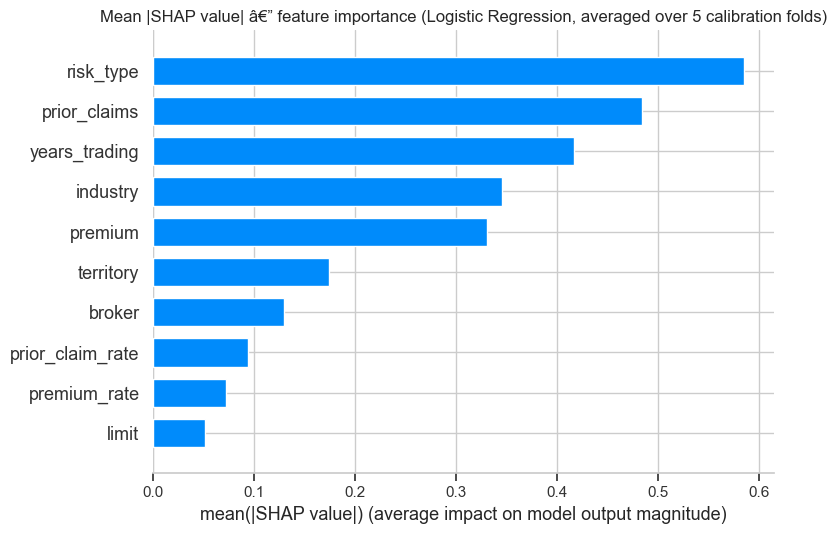


Beeswarm plot â€” direction and magnitude of each feature's effect


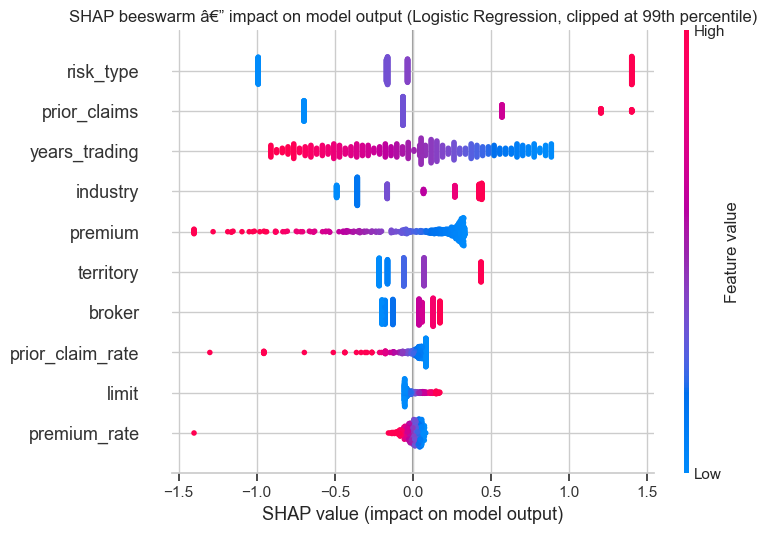


Limitations:
  - SHAP values show the marginal contribution of each feature to each prediction,
    relative to the expected model output (base rate).
  - Averaged over 5 calibration folds; individual folds may differ slightly.
  - 504 training rows is small; SHAP values may shift with more data.
  - Target encoding consolidates categorical signal into one numeric feature per column,
    making SHAP cleaner than one-hot (no fragmentation across broker_X dummies).
  - SHAP measures association, not causation.


In [99]:
import shap

# CalibratedClassifierCV with cv=5 fits 5 base estimators internally.
# We average SHAP values across all 5 folds for a more stable explanation.
# For Logistic Regression, we use LinearExplainer which is exact (no approximation needed).
shap_vals_list = []
for cc in calibrated_clf.calibrated_classifiers_:
    lr = cc.estimator.named_steps["clf"]
    scaler = cc.estimator.named_steps["scaler"]
    X_train_scaled = scaler.transform(X_train)
    explainer = shap.LinearExplainer(lr, X_train_scaled, feature_names=X_train.columns.tolist())
    shap_vals_list.append(explainer.shap_values(X_train_scaled))

shap_values = np.mean(shap_vals_list, axis=0)

print("SHAP summary plot â€” mean |SHAP value| across training set")
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("Mean |SHAP value| â€” feature importance (Logistic Regression, averaged over 5 calibration folds)")
plt.tight_layout()
plt.show()

print("\nBeeswarm plot â€” direction and magnitude of each feature's effect")
# Clip extreme SHAP values so the outlier in premium_rate doesn't compress the axis
clip_limit = np.percentile(np.abs(shap_values), 99)
shap_values_clipped = np.clip(shap_values, -clip_limit, clip_limit)
shap.summary_plot(shap_values_clipped, X_train, show=False)
plt.title("SHAP beeswarm â€” impact on model output (Logistic Regression, clipped at 99th percentile)")
plt.tight_layout()
plt.show()

print("\nLimitations:")
print("  - SHAP values show the marginal contribution of each feature to each prediction,")
print("    relative to the expected model output (base rate).")
print("  - Averaged over 5 calibration folds; individual folds may differ slightly.")
print("  - 504 training rows is small; SHAP values may shift with more data.")
print("  - Target encoding consolidates categorical signal into one numeric feature per column,")
print("    making SHAP cleaner than one-hot (no fragmentation across broker_X dummies).")
print("  - SHAP measures association, not causation.")

## Model Limitations

The following limitations should be understood before using this model in production.

**Data size**
The dataset contains only 504 records. This restricts the model's ability to learn subtle interactions between features and means all performance estimates carry wide uncertainty intervals. The 5-fold CV ROC-AUC of ~0.72 should be treated as approximate; it could shift meaningfully with more data.

**No temporal validation**
Records have no timestamps, so it is impossible to validate the model in a realistic forward-looking way (i.e. train on older records, test on newer ones). If loss-making patterns change over time â€” due to market conditions, inflation, or changing broker behaviour â€” the model will not detect this drift.

**Features available at underwriting time**
The model can only use features that exist at the point a new policy is written: `risk_type`, `territory`, `industry`, `broker`, `limit`, `premium`, `prior_claims`, and `years_trading`. It cannot use `loss_ratio` (which is only known after the policy period ends). Any factors not captured in these fields â€” e.g. specific policy terms, macroeconomic conditions, quality of the insured's management â€” are invisible to the model.

**Categorical sparsity**
Some category combinations (e.g. rare broker Ã— industry pairs) have very few observations. Target encoding with smoothing mitigates this, but predictions for unseen or rare combinations will regress toward the global mean and carry higher uncertainty.

**Association, not causation**
SHAP values and feature importances reflect statistical associations in this dataset. A high `broker` importance, for example, may reflect broker portfolio composition rather than anything intrinsic to the broker. These relationships should be validated with domain expertise before acting on them.

**Threshold sensitivity**
The default 0.5 classification threshold is used throughout. In practice, the optimal threshold depends on the relative costs of false positives (unnecessary review effort) and false negatives (undetected losses). This trade-off should be calibrated with business input using the precision-recall curve above.

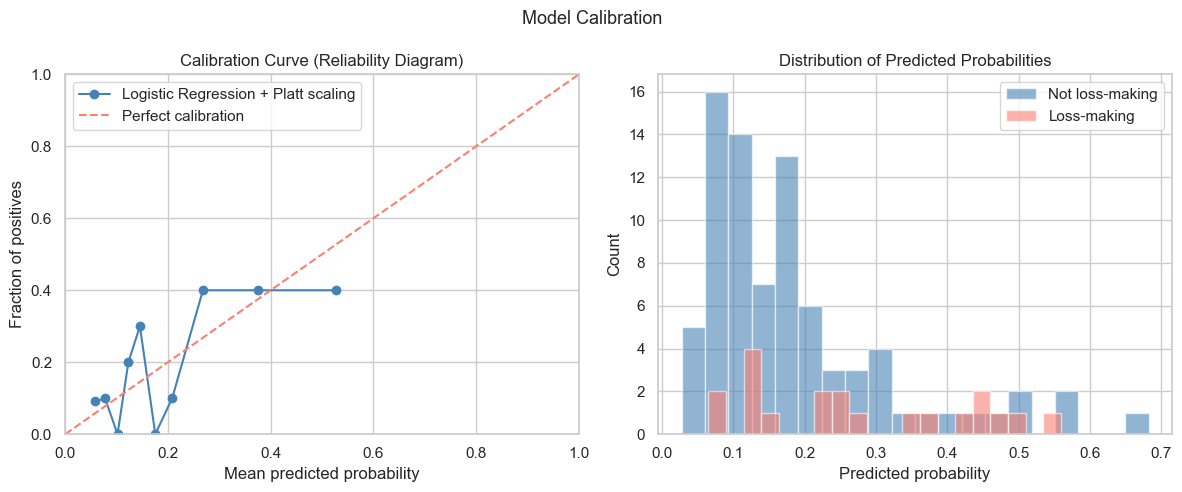

A well-calibrated model should have points close to the diagonal in the reliability diagram.


In [100]:
from sklearn.calibration import calibration_curve

# Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Reliability diagram ---
ax = axes[0]
ax.plot(prob_pred, prob_true, marker="o", color="steelblue", label="Logistic Regression + Platt scaling")
ax.plot([0, 1], [0, 1], linestyle="--", color="salmon", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (Reliability Diagram)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Predicted probability histogram ---
ax2 = axes[1]
ax2.hist(y_proba[y_test == 0], bins=20, alpha=0.6, color="steelblue", label="Not loss-making")
ax2.hist(y_proba[y_test == 1], bins=20, alpha=0.6, color="salmon", label="Loss-making")
ax2.set_xlabel("Predicted probability")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of Predicted Probabilities")
ax2.legend()

plt.suptitle("Model Calibration", fontsize=13)
plt.tight_layout()
plt.show()

print("A well-calibrated model should have points close to the diagonal in the reliability diagram.")

### Calibration Interpretation

**Reliability diagram (left)**

The curve should ideally follow the dashed diagonal â€” meaning that when the model predicts a 40% probability of loss, roughly 40% of those records truly are loss-making. The overall trend is broadly aligned with the diagonal, indicating that Platt scaling has done its job. However, the curve is noticeably erratic, oscillating above and below the ideal line. This is expected: with only ~101 test records spread across 10 bins, each bin contains roughly 10 observations, so a single misclassification swings the fraction of positives by ~10 percentage points. The noise here is a **small sample artefact**, not evidence of systematic miscalibration.

In the mid-range (predicted probabilities 0.35â€“0.55), the model tends to slightly **over-predict** â€” the fraction of actual positives sits below the diagonal. At higher probabilities (â‰¥0.6) the model **under-predicts**, with the final bin jumping sharply to 1.0; this last point is driven by very few records and should not be over-interpreted.

**Probability histogram (right)**

Both classes are clustered tightly between approximately 0.28 and 0.75 â€” the model never issues a confident prediction near 0 or 1. A well-separating model would push the two distributions apart; here they overlap substantially, which is consistent with the 65% accuracy and ROC-AUC of 0.724. There is nevertheless a modest shift: the not-loss-making distribution peaks around 0.40â€“0.45, while the loss-making distribution peaks slightly higher around 0.55â€“0.65, confirming the model has learned *some* discriminative signal.

**Overall**

Calibration is moderate and broadly appropriate for use as a **risk-ranking tool** â€” records with higher predicted probabilities are genuinely more likely to be loss-making. However, the absolute probability values should be treated with caution given the small dataset (~504 rows). With more data, both the calibration curve and the class separation in the histogram would be expected to improve considerably.

## 4. Save Model Artifact

Save your trained model to `../app/artifacts/model.pkl` so the app can load it.

If you built a preprocessing pipeline, save the full pipeline (not just the estimator), so the app can call `pipeline.predict()` directly on raw records.

In [101]:
import datetime

ARTIFACT_PATH = Path("../app/artifacts/model.pkl")
ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Numeric features that exist BEFORE engineering (raw inputs from records.csv)
RAW_NUMERIC_COLS = ["limit", "premium", "prior_claims", "years_trading"]

# Per-feature medians (used at inference to impute missing values)
feature_medians = {
    col: float(X_train[col].median()) for col in X_train.columns
}
# Also store the pre-engineering raw numeric medians for imputation before feature engineering
raw_medians = {
    col: float(df_model[col].median()) for col in RAW_NUMERIC_COLS
}
# Min/max of each raw numeric on the training table â€” used at inference to flag
# values outside the training range (runtime does not impute).
raw_numeric_bounds = {
    col: (float(df_model[col].min()), float(df_model[col].max()))
    for col in RAW_NUMERIC_COLS
}
CAT_COLS_SAVE = ["risk_type", "territory", "industry", "broker"]
raw_categorical_values = {
    col: set(df_model[col].astype(str).str.strip().str.lower().unique())
    for col in CAT_COLS_SAVE
}

# Per-feature outlier bounds (1st / 99th percentile on training data)
# At inference, values outside these bounds are flagged to the caller.
outlier_bounds = {
    col: (float(X_train[col].quantile(0.05)), float(X_train[col].quantile(0.95)))
    for col in X_train.columns
}

artifact = {
    "model": calibrated_clf,
    "encoder": encoder,
    "feature_names": X_train.columns.tolist(),   # ordered list expected by the model
    "feature_medians": feature_medians,           # post-engineering medians
    "raw_medians": raw_medians,                   # pre-engineering medians for imputation
    "raw_numeric_bounds": raw_numeric_bounds,     # (min, max) per raw numeric â€” inference flags
    "raw_categorical_values": raw_categorical_values,  # known category strings â€” inference flags OOV
    "outlier_bounds": outlier_bounds,             # (p1, p99) per feature
    "cat_cols": ["risk_type", "territory", "industry", "broker"],
    "threshold": float(best_threshold),           # F2-optimal decision threshold
    "trained_at": datetime.datetime.now().isoformat(),  # UTC-local timestamp of training run
}

with ARTIFACT_PATH.open("wb") as f:
    pickle.dump(artifact, f)

print(f"Artifact saved to {ARTIFACT_PATH}")
print("Contents:")
print("  artifact['model']           CalibratedClassifierCV (LR + Platt scaling, cv=5)")
print("  artifact['encoder']         TargetEncoder (fitted on training split only)")
print("  artifact['feature_names']   ordered feature list expected by the model")
print("  artifact['feature_medians'] post-engineering per-feature medians (imputation fallback)")
print("  artifact['raw_medians']     pre-engineering numeric medians (limit, premium, etc.)")
print("  artifact['raw_numeric_bounds']  (min, max) per raw numeric for extreme-value flagging")
print("  artifact['raw_categorical_values']  known category strings for OOV flagging")
print("  artifact['outlier_bounds']  (p1, p99) per feature for OOD flagging")
print("  artifact['cat_cols']       categorical columns to pass through the encoder")
print(f"  artifact['trained_at']     {artifact['trained_at']}")
print(f"  artifact['threshold']       {artifact['threshold']}  (F2-optimal decision threshold)")

Artifact saved to ..\app\artifacts\model.pkl
Contents:
  artifact['model']           CalibratedClassifierCV (LR + Platt scaling, cv=5)
  artifact['encoder']         TargetEncoder (fitted on training split only)
  artifact['feature_names']   ordered feature list expected by the model
  artifact['feature_medians'] post-engineering per-feature medians (imputation fallback)
  artifact['raw_medians']     pre-engineering numeric medians (limit, premium, etc.)
  artifact['raw_numeric_bounds']  (min, max) per raw numeric for extreme-value flagging
  artifact['raw_categorical_values']  known category strings for OOV flagging
  artifact['outlier_bounds']  (p1, p99) per feature for OOD flagging
  artifact['cat_cols']       categorical columns to pass through the encoder
  artifact['trained_at']     2026-04-06T13:00:20.833220
  artifact['threshold']       0.12000000000000001  (F2-optimal decision threshold)
